In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

df_all = pd.read_csv('/Users/shahil/Documents/UCSB/2025-2026/P3/capstone2026.csv')

In [19]:
# Group shots by location x type (free throws get a single group)
df_all['group'] = df_all.apply(
    lambda r: r['Shot.Location']
    if r['Shot.Location'] == 'Free Throw'
    else f"{r['Shot.Location']} – {r['Shot.Type']}",
    axis=1
)

# Numeric feature columns only
exclude_cols = ['Name', 'Date', 'Shot.Type', 'Shot.Location', 'Made',
                'PlayerID', 'group', 'Shot.X.Pos', 'Shot.Y.Pos', 'Shot.Distance']
feature_cols = [c for c in df_all.columns
                if c not in exclude_cols and df_all[c].dtype in ['float64','int64','float32','int32']]

print(f"Features: {len(feature_cols)}")
print(f"Groups:   {df_all['group'].nunique()}\n")

for g, n in df_all.groupby('group').size().sort_values(ascending=False).items():
    print(f"  {g}: {n}")

Features: 253
Groups:   23

  Middle Three – Catch and Shoot: 4274
  Left Corner Three – Off the Dribble: 3996
  Free Throw: 3967
  Right Corner Three – Catch and Shoot: 2620
  Right Corner Three – Off the Dribble: 2338
  Key – Off the Dribble: 1301
  Right Wing Three – Catch and Shoot: 1058
  Left Wing Three – Catch and Shoot: 1023
  Left Corner Three – Catch and Shoot: 994
  Middle Three – Off the Dribble: 730
  Left Wing Three – Off the Dribble: 545
  Key – Catch and Shoot: 519
  Middle Two – Catch and Shoot: 461
  Right Wing Three – Off the Dribble: 378
  Left Corner Two – Off the Dribble: 333
  Right Corner Two – Catch and Shoot: 296
  Left Corner Two – Catch and Shoot: 263
  Right Corner Two – Off the Dribble: 229
  Middle Two – Off the Dribble: 141
  Left Wing Two – Catch and Shoot: 116
  Right Wing Two – Catch and Shoot: 103
  Right Wing Two – Off the Dribble: 95
  Left Wing Two – Off the Dribble: 88


In [20]:
# Remove highly correlated features (|r| > 0.90)
def drop_correlated(X, threshold=0.90):
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return X.drop(columns=to_drop), to_drop

X_preview = df_all[feature_cols].dropna(axis=1, how='all').fillna(df_all[feature_cols].median())
_, dropped_preview = drop_correlated(X_preview, threshold=0.90)

print(f"Before:  {len(feature_cols)}")
print(f"Dropped: {len(dropped_preview)}")
print(f"After:   {len(feature_cols) - len(dropped_preview)}\n")
for f in sorted(dropped_preview):
    print(f"  {f}")

Before:  253
Dropped: 128
After:   125

  BallXHitch
  BallXPostHitch
  BallXRelease
  BallYHitch
  BallYPostHitch
  BallYRelease
  BallZPreHitch
  BallZRelease
  HipAlignmentHitch
  HipAlignmentPostHitch
  HipAlignmentPreHitch
  HipAlignmentRelease
  PercTimePreHitch
  PostHitchXDelta
  PostHitchYDelta
  ShoulderAlignmentPostHitch
  ShoulderAlignmentRelease
  ankleTotalROMAvg
  hipTotalROMAvg
  maxAnkleDorsiflexionAvgHitch
  maxAnkleDorsiflexionAvgPostHitch
  maxAnkleDorsiflexionRightPostHitch
  maxAnklePlantarflexionAvgHitch
  maxAnklePlantarflexionAvgPostHitch
  maxAnklePlantarflexionLeftHitch
  maxAnklePlantarflexionRightHitch
  maxElbowExtensionRightHitch
  maxHipExtensionAvgHitch
  maxHipExtensionAvgPostHitch
  maxHipExtensionAvgPreHitch
  maxHipExtensionLeftHitch
  maxHipExtensionLeftPreHitch
  maxHipExtensionRightHitch
  maxHipExtensionRightPreHitch
  maxHipFlexionAvgHitch
  maxHipFlexionAvgPostHitch
  maxHipFlexionAvgPreHitch
  maxKneeExtensionAvgHitch
  maxKneeExtensionAvgPos

In [ ]:
# Fit logistic elastic net per group (players with 20+ shots)
results = {}

for grp_name, grp_df in df_all.groupby('group'):

    player_counts = grp_df['Name'].value_counts()
    eligible_players = player_counts[player_counts >= 20].index
    grp_df = grp_df[grp_df['Name'].isin(eligible_players)].copy()

    if len(grp_df) < 30:
        print(f"  skip {grp_name} ({len(grp_df)} rows)")
        continue
    if grp_df['Made'].nunique() < 2:
        print(f"  skip {grp_name} (single class)")
        continue

    X = grp_df[feature_cols].copy()
    y = grp_df['Made'].astype(int)

    X = X.dropna(axis=1, how='all')
    X = X.loc[:, X.std() > 0]
    X, _ = drop_correlated(X, threshold=0.90)
    X = X.fillna(X.median())

    if X.shape[1] == 0:
        continue

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    log_enet = LogisticRegressionCV(
        penalty='elasticnet',
        l1_ratios=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
        Cs=np.logspace(-2, 3, 30),
        cv=5, solver='saga', max_iter=20000,
        random_state=42, n_jobs=-1, scoring='roc_auc'
    )
    log_enet.fit(X_scaled, y)

    coefs = pd.Series(log_enet.coef_[0], index=X.columns)
    nonzero = coefs[coefs != 0].sort_values(key=abs, ascending=False)

    y_prob = log_enet.predict_proba(X_scaled)[:, 1]
    auc = roc_auc_score(y, y_prob)
    acc = log_enet.score(X_scaled, y)

    results[grp_name] = {
        'C': log_enet.C_[0],
        'l1_ratio': log_enet.l1_ratio_[0],
        'n_samples': len(grp_df),
        'n_players': grp_df['Name'].nunique(),
        'n_features_used': len(nonzero),
        'n_features_total': X.shape[1],
        'coefs': nonzero,
        'auc': auc,
        'accuracy': acc
    }

    print(f"{grp_name}  |  n={len(grp_df)}, players={grp_df['Name'].nunique()}  |  "
          f"C={log_enet.C_[0]:.4f}, l1={log_enet.l1_ratio_[0]}  |  "
          f"AUC={auc:.4f}, Acc={acc:.4f}  |  "
          f"nonzero: {len(nonzero)}/{X.shape[1]}")

print(f"\nGroups analyzed: {len(results)}")

Free Throw  |  n=3716, players=97  |  C=0.0100, l1=0.9  |  AUC=0.9151, Acc=0.9151  |  nonzero: 1/108
Key – Catch and Shoot  |  n=388, players=2  |  C=0.3562, l1=0.99  |  AUC=0.9541, Acc=0.9541  |  nonzero: 21/126
Key – Catch and Shoot  |  n=388, players=2  |  C=0.3562, l1=0.99  |  AUC=0.9541, Acc=0.9541  |  nonzero: 21/126
Key – Off the Dribble  |  n=1142, players=13  |  C=0.0100, l1=0.7  |  AUC=0.8928, Acc=0.8928  |  nonzero: 1/138
Key – Off the Dribble  |  n=1142, players=13  |  C=0.0100, l1=0.7  |  AUC=0.8928, Acc=0.8928  |  nonzero: 1/138
Left Corner Three – Catch and Shoot  |  n=550, players=9  |  C=0.0728, l1=0.99  |  AUC=0.9762, Acc=0.9762  |  nonzero: 5/152
Left Corner Three – Catch and Shoot  |  n=550, players=9  |  C=0.0728, l1=0.99  |  AUC=0.9762, Acc=0.9762  |  nonzero: 5/152
Left Corner Three – Off the Dribble  |  n=3471, players=95  |  C=0.0489, l1=0.99  |  AUC=0.9653, Acc=0.9653  |  nonzero: 13/124
Left Corner Three – Off the Dribble  |  n=3471, players=95  |  C=0.0489, 

In [ ]:
# Top 15 features per group by |coefficient|
for grp_name in sorted(results.keys()):
    r = results[grp_name]
    top = r['coefs'].head(15)
    if len(top) == 0:
        continue

    print(f"\n{'='*70}")
    print(f"  {grp_name}")
    print(f"  n={r['n_samples']}, players={r['n_players']}, AUC={r['auc']:.4f}, "
          f"Acc={r['accuracy']:.4f}, C={r['C']:.4f}, l1_ratio={r['l1_ratio']}")
    print(f"  Nonzero: {r['n_features_used']}/{r['n_features_total']}")
    print(f"{'='*70}")

    for feat, coef in top.items():
        direction = "+make" if coef > 0 else "-miss"
        print(f"  {coef:+.4f}  {direction}  {feat}")


  Free Throw
  n=3716, players=97, AUC=0.9151, Acc=0.9151, C=0.0100, l1_ratio=0.9
  Non-zero features: 1/108
  -1.6671  ↓ MISS  Ball.Distance.from.Center

  Key – Catch and Shoot
  n=388, players=2, AUC=0.9541, Acc=0.9541, C=0.3562, l1_ratio=0.99
  Non-zero features: 21/126
  -3.5885  ↓ MISS  Ball.Distance.from.Center
  -1.0842  ↓ MISS  Ball_Depth
  -0.3299  ↓ MISS  Release.Height
  -0.3197  ↓ MISS  maxTorsoFlexionPostHitch
  -0.2514  ↓ MISS  timeAtStartofMovement
  -0.2293  ↓ MISS  HitchYDelta
  +0.1998  ↑ MAKE  BallVeloPreHitch
  +0.1569  ↑ MAKE  Post.Hitch.Time
  -0.1516  ↓ MISS  TorsoVeloRelease
  +0.1408  ↑ MAKE  BallVeloStart
  +0.0703  ↑ MAKE  timeToMaxShoulderExtensionLeftPostHitch
  +0.0649  ↑ MAKE  ShoulderTotalROMLeft
  -0.0517  ↓ MISS  HipFlexionAtT0Avg
  +0.0399  ↑ MAKE  maxAnklePlantarflexionRightPostHitch
  -0.0381  ↓ MISS  maxShoulderFlexionRightHitch

  Key – Off the Dribble
  n=1142, players=13, AUC=0.8928, Acc=0.8928, C=0.0100, l1_ratio=0.7
  Non-zero features: 1/13

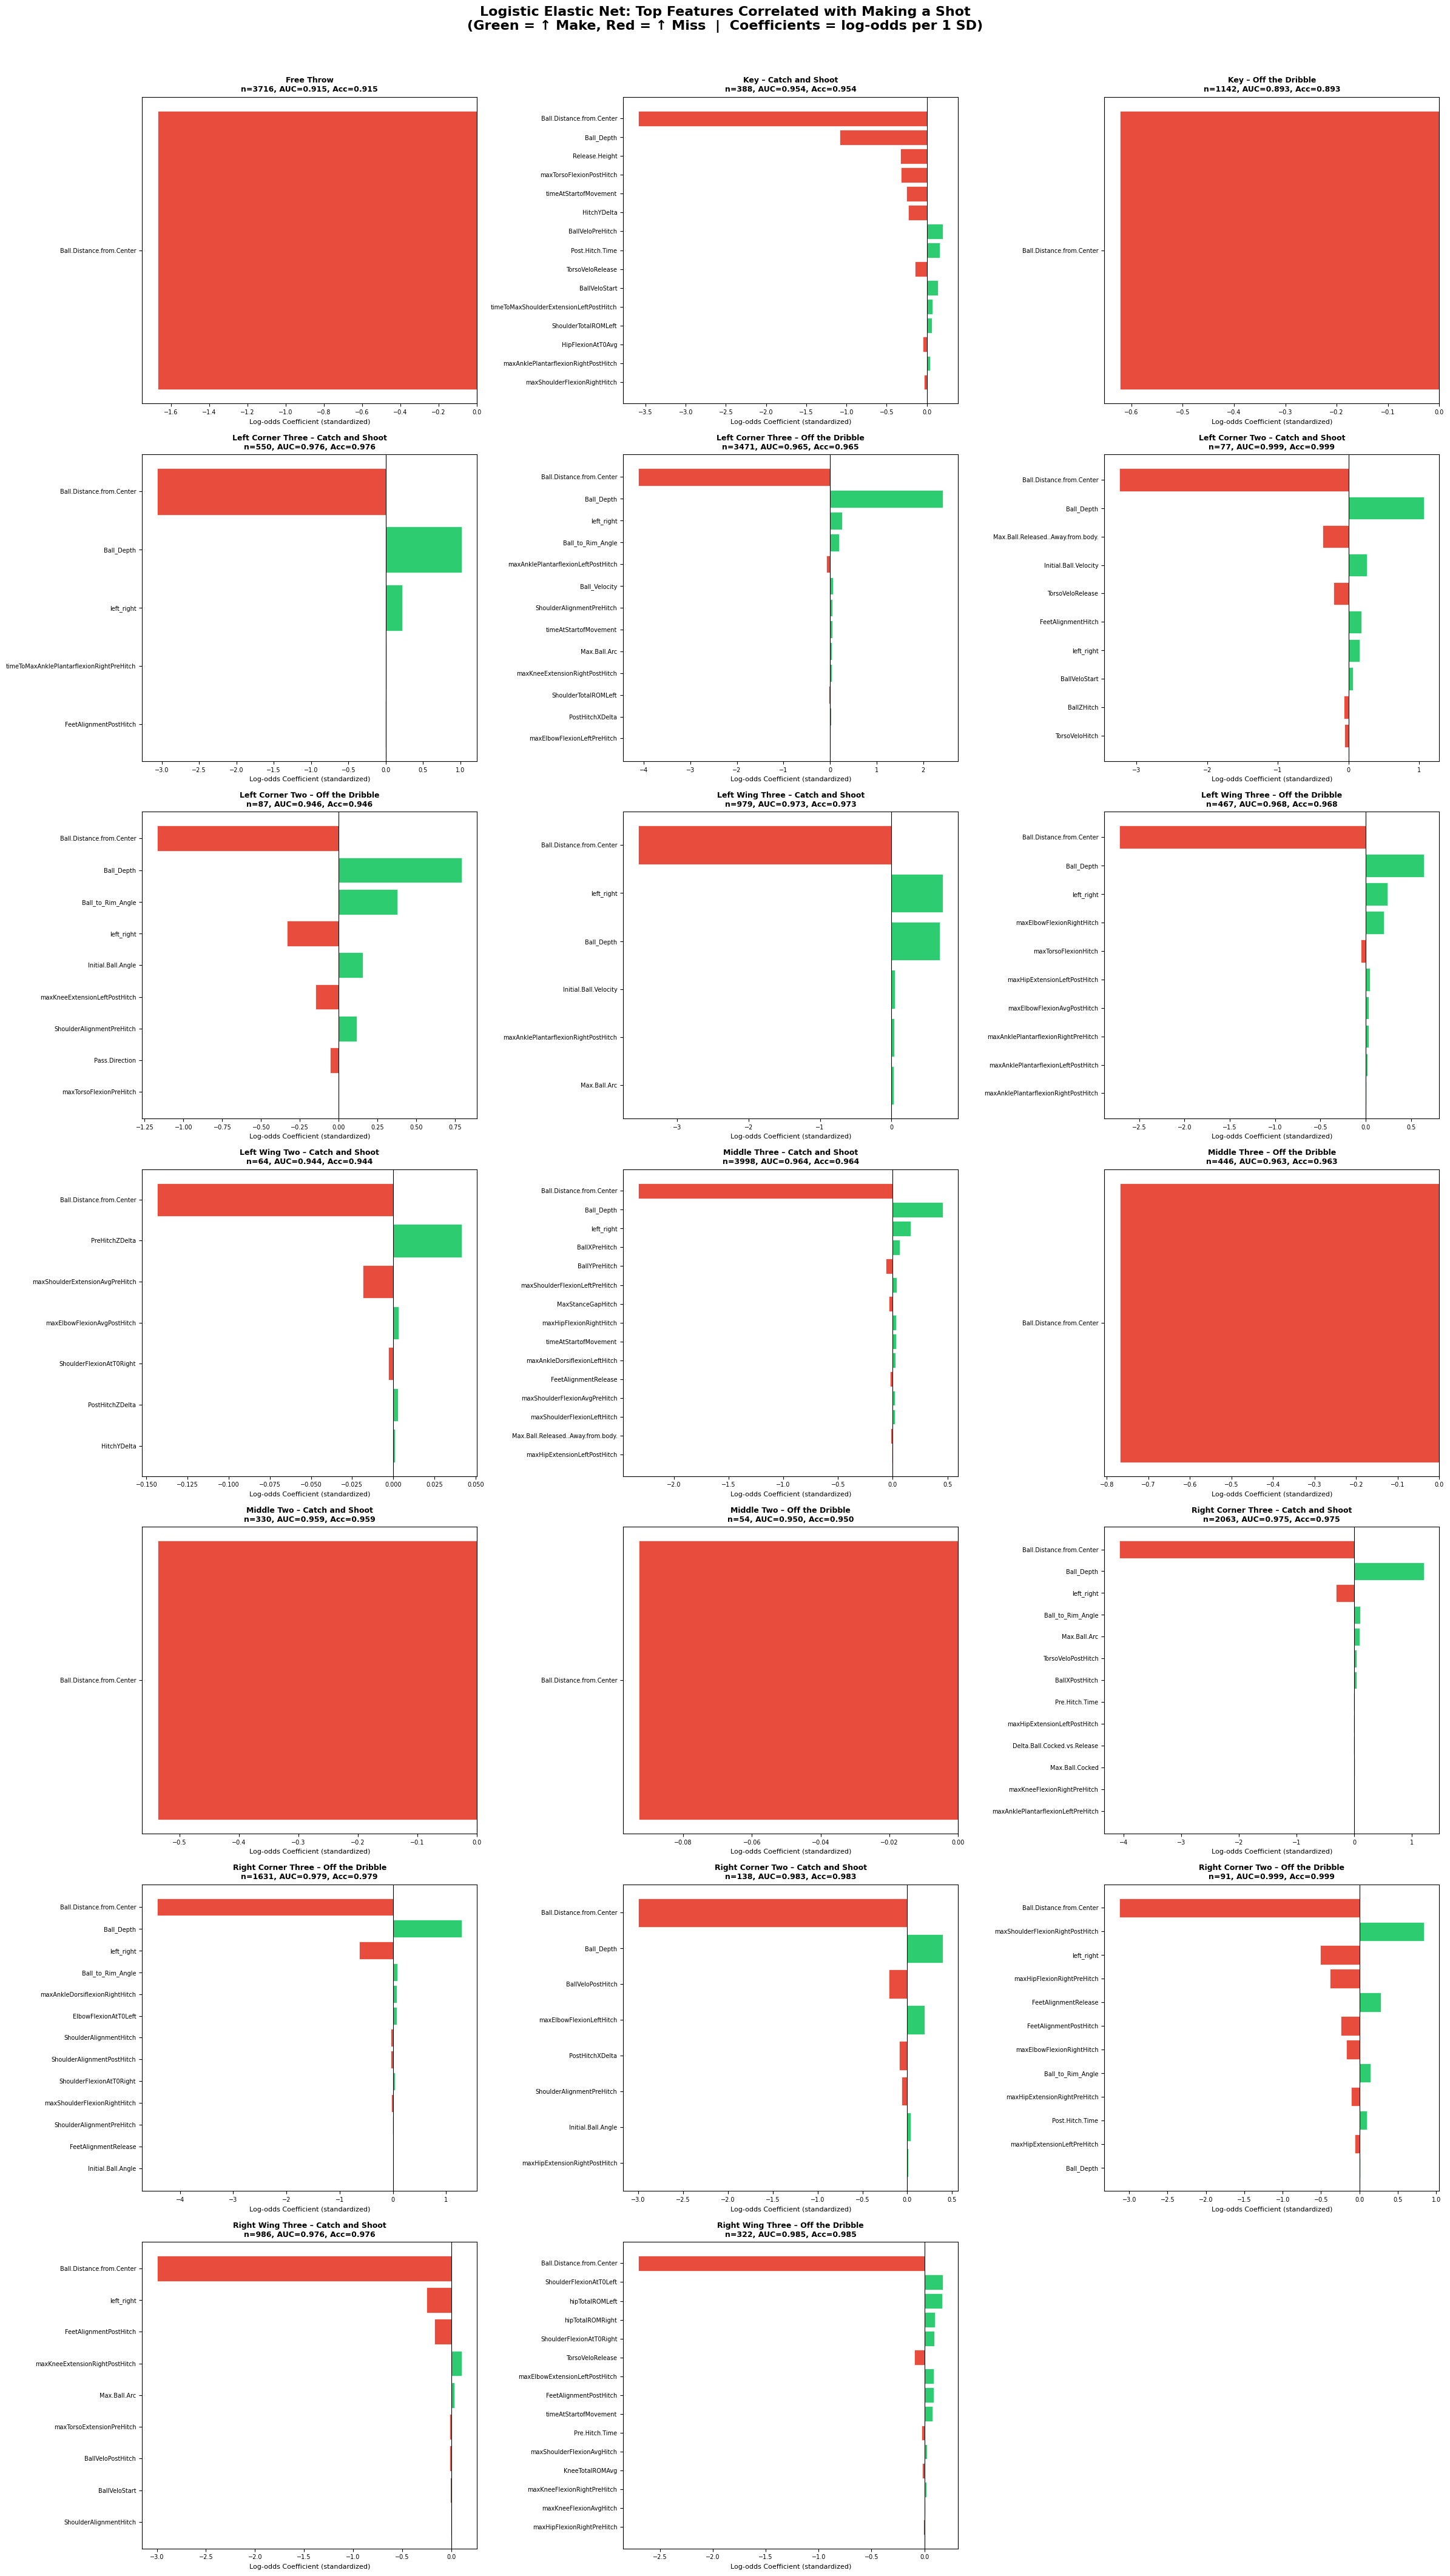

In [ ]:
# Coefficient bar plots per group
sorted_groups = sorted(results.keys())
n_groups = len(sorted_groups)
n_cols = 3
n_rows = int(np.ceil(n_groups / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 6 * n_rows))
axes = axes.flatten()

for idx, grp_name in enumerate(sorted_groups):
    ax = axes[idx]
    r = results[grp_name]
    top = r['coefs'].head(15)

    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top.values]
    ax.barh(range(len(top)), top.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=7)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"{grp_name}\nn={r['n_samples']}, AUC={r['auc']:.3f}, Acc={r['accuracy']:.3f}",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Log-odds coefficient (standardized)', fontsize=8)
    ax.tick_params(axis='x', labelsize=7)

for idx in range(n_groups, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Logistic Elastic Net: Top Features per Group\n'
             '(Green = positive/make, Red = negative/miss)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

  FEATURES MOST FREQUENTLY SELECTED ACROSS ALL SHOT LOCATION × TYPE GROUPS
  (out of 20 total groups  |  Logistic Elastic Net)

                             Feature  Groups Selected  Avg Coefficient  Median Coefficient  Positive (Make)  Negative (Miss)
           Ball.Distance.from.Center               20        -2.395543           -2.856056                0               20
                          Ball_Depth               12         0.743288            0.738592               11                1
                          left_right               11        -0.026342            0.160421                6                5
              FeetAlignmentPostHitch                5        -0.068529           -0.008537                1                4
                   Ball_to_Rim_Angle                5         0.180659            0.144168                5                0
               timeAtStartofMovement                4        -0.024464            0.037474                3               

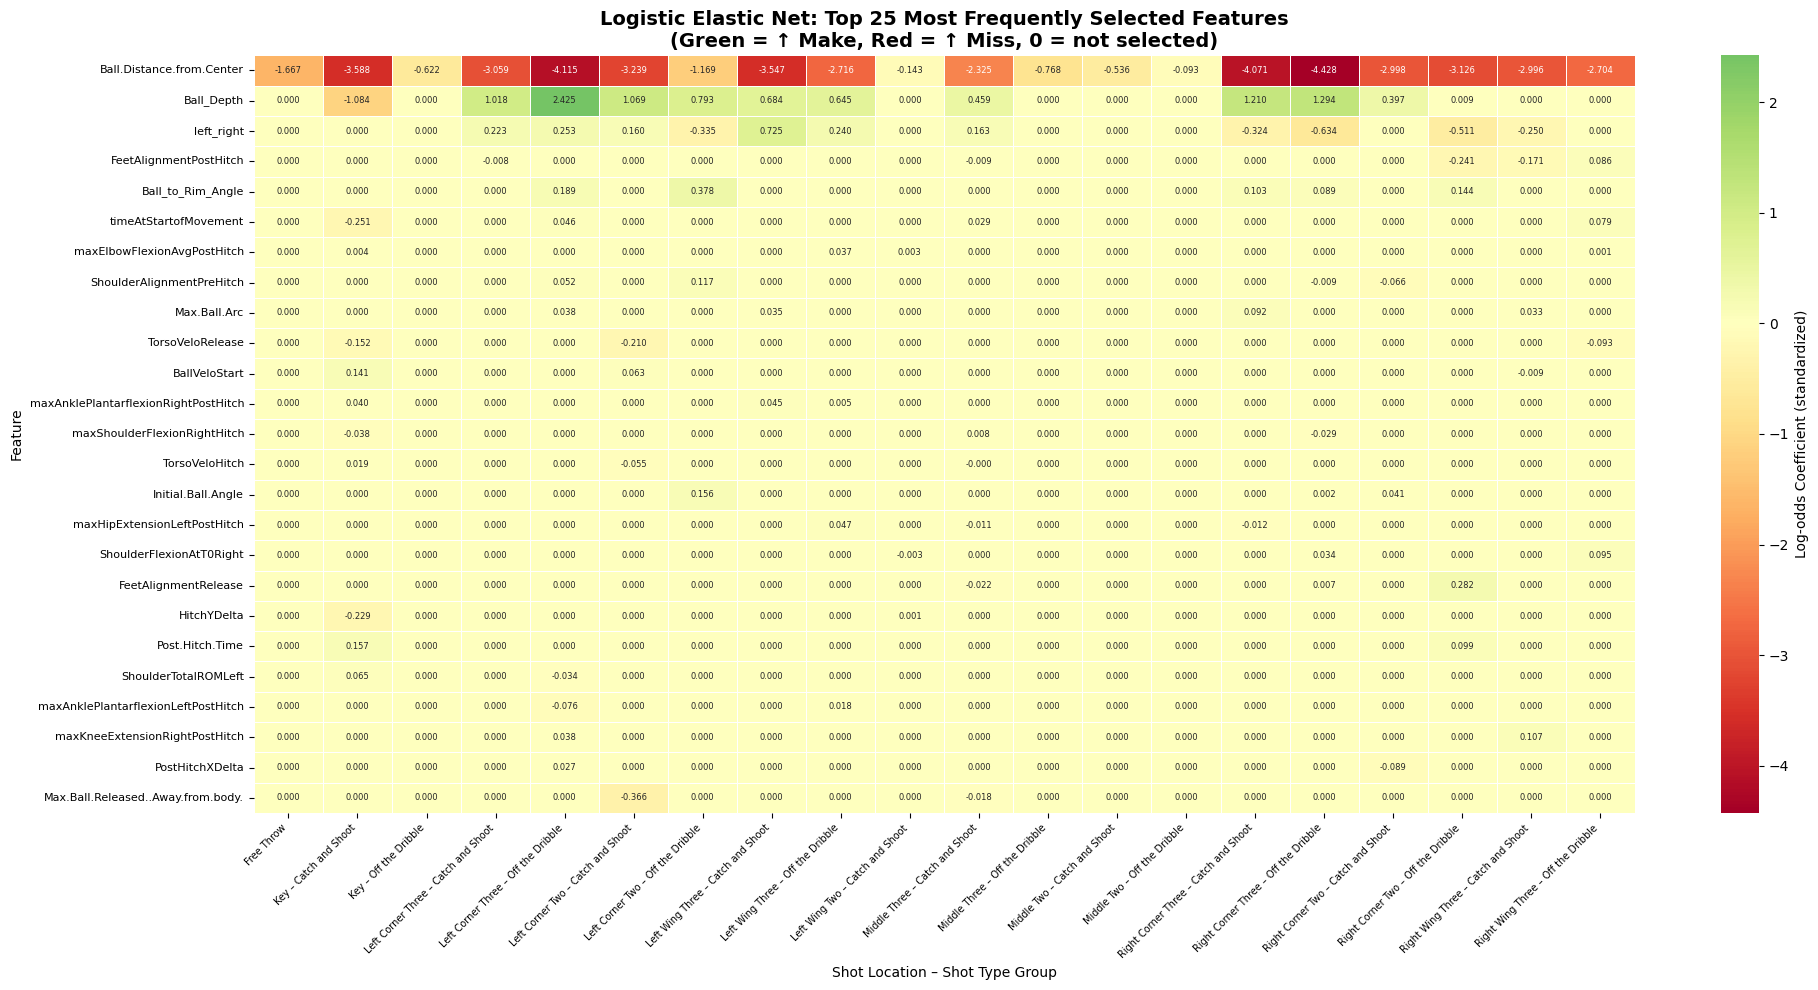

In [ ]:
# Feature frequency across groups
feat_counts = Counter()
feat_direction = {}

for grp_name, r in results.items():
    for feat, coef in r['coefs'].items():
        feat_counts[feat] += 1
        feat_direction.setdefault(feat, []).append(coef)

summary_df = pd.DataFrame([
    {
        'Feature': feat,
        'Groups Selected': count,
        'Avg Coefficient': np.mean(feat_direction[feat]),
        'Median Coefficient': np.median(feat_direction[feat]),
        'Positive (Make)': sum(1 for c in feat_direction[feat] if c > 0),
        'Negative (Miss)': sum(1 for c in feat_direction[feat] if c < 0),
    }
    for feat, count in feat_counts.most_common()
])

print(f"Features selected across {len(results)} groups (top 30):\n")
print(summary_df.head(30).to_string(index=False))

# Heatmap of top 25 features
top_feats = [f for f, _ in feat_counts.most_common(25)]

heatmap_data = pd.DataFrame(0.0, index=top_feats, columns=sorted(results.keys()))
for grp_name, r in results.items():
    for feat in top_feats:
        if feat in r['coefs'].index:
            heatmap_data.loc[feat, grp_name] = r['coefs'][feat]

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(heatmap_data, cmap='RdYlGn', center=0, annot=True, fmt='.3f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Log-odds coefficient'},
            annot_kws={'size': 6})
ax.set_title('Top 25 Features by Selection Frequency (0 = not selected)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Group', fontsize=10)
ax.set_ylabel('Feature', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Bootstrap stability (200 resamples per group)
n_bootstrap = 200
stability_results = {}

for grp_name, grp_df_full in df_all.groupby('group'):
    if grp_name not in results:
        continue

    r = results[grp_name]
    top_feats = r['coefs'].head(10).index.tolist()
    if not top_feats:
        continue

    player_counts = grp_df_full['Name'].value_counts()
    eligible = player_counts[player_counts >= 20].index
    grp_df = grp_df_full[grp_df_full['Name'].isin(eligible)].copy()

    X = grp_df[feature_cols].copy()
    y = grp_df['Made'].astype(int)
    X = X.dropna(axis=1, how='all')
    X = X.loc[:, X.std() > 0]
    X, _ = drop_correlated(X, threshold=0.90)
    X = X.fillna(X.median())

    valid_feats = [f for f in top_feats if f in X.columns]
    if not valid_feats:
        continue

    boot_coefs = {f: [] for f in valid_feats}

    for b in range(n_bootstrap):
        idx = np.random.RandomState(b).choice(len(X), size=len(X), replace=True)
        X_b, y_b = X.iloc[idx], y.iloc[idx]

        if y_b.nunique() < 2:
            continue

        scaler = StandardScaler()
        X_bs = scaler.fit_transform(X_b)

        model = LogisticRegression(
            penalty='elasticnet', solver='saga',
            C=r['C'], l1_ratio=r['l1_ratio'],
            max_iter=20000, random_state=42
        )
        model.fit(X_bs, y_b)

        coef_series = pd.Series(model.coef_[0], index=X.columns)
        for f in valid_feats:
            boot_coefs[f].append(coef_series[f])

    stability_results[grp_name] = {
        f: {
            'mean': np.mean(boot_coefs[f]),
            'std': np.std(boot_coefs[f]),
            'pct_nonzero': np.mean([c != 0 for c in boot_coefs[f]]) * 100,
            'ci_low': np.percentile(boot_coefs[f], 2.5),
            'ci_high': np.percentile(boot_coefs[f], 97.5),
        }
        for f in valid_feats
    }
    print(f"  {grp_name} done")

# Print results
print(f"\nBootstrap stability (200 resamples)")
print(f"  >80% nonzero = stable, 50-80% = marginal, <50% = unstable\n")

for grp_name in sorted(stability_results.keys()):
    print(f"  {grp_name}  (n={results[grp_name]['n_samples']})")
    print(f"  {'Feature':<40} {'Mean':>7} {'Std':>7} {'%NZ':>6} {'95% CI':>20}")
    print(f"  {'-'*40} {'-'*7} {'-'*7} {'-'*6} {'-'*20}")
    for feat, s in stability_results[grp_name].items():
        tag = "stable" if s['pct_nonzero'] > 80 else "marginal" if s['pct_nonzero'] > 50 else "unstable"
        print(f"  {feat:<40} {s['mean']:+.4f} {s['std']:.4f} {s['pct_nonzero']:5.1f}%  "
              f"[{s['ci_low']:+.4f}, {s['ci_high']:+.4f}] {tag}")
    print()

✅ Free Throw bootstrap done
✅ Key – Catch and Shoot bootstrap done
✅ Key – Off the Dribble bootstrap done
✅ Left Corner Three – Catch and Shoot bootstrap done
✅ Left Corner Three – Off the Dribble bootstrap done
✅ Left Corner Two – Catch and Shoot bootstrap done
✅ Left Corner Two – Off the Dribble bootstrap done
✅ Left Wing Three – Catch and Shoot bootstrap done
✅ Left Wing Three – Off the Dribble bootstrap done
✅ Left Wing Two – Catch and Shoot bootstrap done
✅ Middle Three – Catch and Shoot bootstrap done
✅ Middle Three – Off the Dribble bootstrap done
✅ Middle Two – Catch and Shoot bootstrap done
✅ Middle Two – Off the Dribble bootstrap done
✅ Right Corner Three – Catch and Shoot bootstrap done
✅ Right Corner Three – Off the Dribble bootstrap done
✅ Right Corner Two – Catch and Shoot bootstrap done
✅ Right Corner Two – Off the Dribble bootstrap done
✅ Right Wing Three – Catch and Shoot bootstrap done
✅ Right Wing Three – Off the Dribble bootstrap done

  BOOTSTRAP STABILITY ANALYSIS

  🏀 FINAL RANKED FEATURES: Frequently Selected + Bootstrap Stable (>80%)
  Across 20 shot location × type groups

                         Feature  Stable Groups  Total Groups Direction  Avg Coef Consistent
       Ball.Distance.from.Center             20            20    ↓ MISS -2.410122          ✅
                      Ball_Depth             11            11     Mixed  0.796478         ⚠️
                      left_right              9            11     Mixed -0.001174         ⚠️
               Ball_to_Rim_Angle              4             5    ↑ MAKE  0.159989          ✅
           timeAtStartofMovement              1             4    ↓ MISS -0.241307          ✅
                  PreHitchZDelta              1             1    ↑ MAKE  0.033892          ✅
                   BallXPreHitch              1             1    ↑ MAKE  0.056226          ✅
                   BallYPreHitch              1             1    ↓ MISS -0.052417          ✅
maxShoulderFlexionRightPostHitch              1  

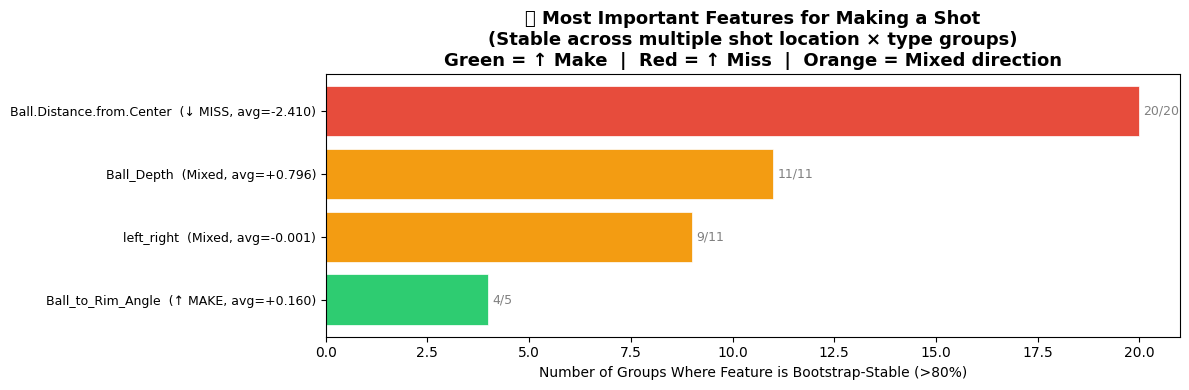


  DETAIL: Which groups each top feature is stable in

  📌 Ball.Distance.from.Center  (↓ MISS, stable in 20 groups)
     Free Throw                                    coef=-1.6780  [-1.7797, -1.5588]  nonzero=100%
     Key – Catch and Shoot                         coef=-3.7332  [-4.6406, -2.9528]  nonzero=100%
     Key – Off the Dribble                         coef=-0.6354  [-0.8164, -0.4648]  nonzero=100%
     Left Corner Three – Catch and Shoot           coef=-3.0546  [-3.4184, -2.6266]  nonzero=100%
     Left Corner Three – Off the Dribble           coef=-4.1538  [-4.4812, -3.8728]  nonzero=100%
     Left Corner Two – Catch and Shoot             coef=-3.0663  [-3.4690, -2.6181]  nonzero=100%
     Left Corner Two – Off the Dribble             coef=-1.3155  [-2.0655, -0.6852]  nonzero=100%
     Left Wing Three – Catch and Shoot             coef=-3.5789  [-3.9669, -3.1864]  nonzero=100%
     Left Wing Three – Off the Dribble             coef=-2.7167  [-3.3748, -2.0412]  nonzero=100%
  

In [ ]:
# Final ranking: features that are both frequently selected and bootstrap-stable (>80%)
stable_counts = Counter()
total_appearances = Counter()
stable_coefs = {}

for grp_name, feats in stability_results.items():
    for feat, s in feats.items():
        total_appearances[feat] += 1
        if s['pct_nonzero'] > 80:
            stable_counts[feat] += 1
            stable_coefs.setdefault(feat, []).append(s['mean'])

final_rows = []
for feat, stable_grp_count in stable_counts.most_common():
    coef_vals = stable_coefs[feat]
    avg_coef = np.mean(coef_vals)
    pos = sum(1 for c in coef_vals if c > 0)
    neg = sum(1 for c in coef_vals if c < 0)

    if pos > 0 and neg == 0:
        direction = "+make"
    elif neg > 0 and pos == 0:
        direction = "-miss"
    else:
        direction = "mixed"

    stable_in = [g for g, fs in stability_results.items()
                 if feat in fs and fs[feat]['pct_nonzero'] > 80]

    final_rows.append({
        'Feature': feat,
        'Stable Groups': stable_grp_count,
        'Total Groups': total_appearances[feat],
        'Direction': direction,
        'Avg Coef': avg_coef,
        'Consistent': "yes" if (pos == 0 or neg == 0) else "no",
        'Stable In': ', '.join(sorted(stable_in))
    })

final_df = pd.DataFrame(final_rows)

print(f"Final ranked features (stable >80%, across {len(results)} groups):\n")
print(final_df[['Feature', 'Stable Groups', 'Total Groups', 'Direction',
                'Avg Coef', 'Consistent']].to_string(index=False))

# Plot features stable in 2+ groups
plot_df = final_df[final_df['Stable Groups'] >= 2].copy()

if len(plot_df) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, len(plot_df) * 0.5)))

    colors = []
    for _, row in plot_df.iterrows():
        if row['Direction'] == '+make':
            colors.append('#2ecc71')
        elif row['Direction'] == '-miss':
            colors.append('#e74c3c')
        else:
            colors.append('#f39c12')

    ax.barh(range(len(plot_df)), plot_df['Stable Groups'], color=colors,
            edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels([f"{row['Feature']}  ({row['Direction']}, avg={row['Avg Coef']:+.3f})"
                        for _, row in plot_df.iterrows()], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Groups where feature is bootstrap-stable (>80%)', fontsize=10)
    ax.set_title('Features Stable Across Multiple Groups\n'
                 '(green = +make, red = -miss, orange = mixed)',
                 fontsize=13, fontweight='bold')

    for i, (_, row) in enumerate(plot_df.iterrows()):
        ax.text(row['Stable Groups'] + 0.1, i, f"{row['Stable Groups']}/{row['Total Groups']}",
                va='center', fontsize=9, color='gray')

    plt.tight_layout()
    plt.show()
else:
    print("\nNo features stable in 2+ groups.")

# Per-feature detail
print(f"\nPer-feature breakdown (stable in 2+ groups):")
print(f"{'='*80}")
for _, row in final_df[final_df['Stable Groups'] >= 2].iterrows():
    print(f"\n  {row['Feature']}  ({row['Direction']}, {row['Stable Groups']} groups)")
    for grp in sorted(row['Stable In'].split(', ')):
        s = stability_results[grp][row['Feature']]
        print(f"     {grp:<45} coef={s['mean']:+.4f}  [{s['ci_low']:+.4f}, {s['ci_high']:+.4f}]  "
              f"nz={s['pct_nonzero']:.0f}%")

In [ ]:
# Check specific biomechanical features
bio_feats = ['maxShoulderFlexionRightPostHitch', 'FeetAlignmentPostHitch', 'hipTotalROMLeft']
for _, row in final_df[final_df['Feature'].isin(bio_feats)].iterrows():
    print(f"{row['Feature']}  |  Stable in: {row['Stable In']}")
    print(f"   Direction: {row['Direction']},  Avg Coef: {row['Avg Coef']:.4f}\n")

maxShoulderFlexionRightPostHitch  →  Stable in: Right Corner Two – Off the Dribble
   Direction: ↑ MAKE,  Avg Coef: 0.6218

FeetAlignmentPostHitch  →  Stable in: Right Wing Three – Catch and Shoot
   Direction: ↓ MISS,  Avg Coef: -0.1520

hipTotalROMLeft  →  Stable in: Right Wing Three – Off the Dribble
   Direction: ↑ MAKE,  Avg Coef: 0.1252

